In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_datareader as data

plt.style.use('fivethirtyeight')
%matplotlib inline

In [2]:
import yfinance as yf
import datetime as dt

stock = "POWERGRID.NS"
start = dt.datetime(2000, 1, 1)
end = dt.datetime(2025, 11, 1)

df = yf.download(stock, start=start, end=end, auto_adjust=False)

[*********************100%***********************]  1 of 1 completed


In [3]:
df.head()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
Date,,,,,,
2007-10-05,32.405319,56.587513,61.593765,46.771885,50.512512,855215656
2007-10-08,30.746395,53.690639,58.500015,53.353138,58.500015,126671715
2007-10-09,32.840179,57.346889,57.853138,50.821888,53.718761,116725709
2007-10-10,33.146187,57.881264,59.062515,57.375015,58.837513,67931378
2007-10-11,36.850571,64.350014,67.500015,57.375015,67.500015,106320954


In [4]:
df.shape

(4430, 6)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4430 entries, 2007-10-05 to 2025-09-22
Data columns (total 6 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   (Adj Close, POWERGRID.NS)  4430 non-null   float64
 1   (Close, POWERGRID.NS)      4430 non-null   float64
 2   (High, POWERGRID.NS)       4430 non-null   float64
 3   (Low, POWERGRID.NS)        4430 non-null   float64
 4   (Open, POWERGRID.NS)       4430 non-null   float64
 5   (Volume, POWERGRID.NS)     4430 non-null   int64  
dtypes: float64(5), int64(1)
memory usage: 242.3 KB


In [6]:
df.isnull().sum()

Price      Ticker      
Adj Close  POWERGRID.NS    0
Close      POWERGRID.NS    0
High       POWERGRID.NS    0
Low        POWERGRID.NS    0
Open       POWERGRID.NS    0
Volume     POWERGRID.NS    0
dtype: int64

In [7]:
df.describe()

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
count,4430.000000,4430.000000,4430.000000,4430.000000,4430.000000,4.430000e+03
mean,89.869269,113.760071,115.236970,112.312186,113.822878,1.191947e+07
std,77.474961,72.420305,73.213997,71.612893,72.419011,2.014566e+07
min,18.919928,32.625008,34.875008,29.250008,34.706257,0.000000e+00
25%,36.726368,60.869546,61.706264,60.138295,61.059391,4.928581e+06
50%,66.699001,91.842209,93.375023,90.421894,91.715649,8.534480e+06
75%,100.322071,124.804716,126.555500,123.257841,124.804716,1.377628e+07
max,354.580750,365.450012,366.250000,357.200012,364.049988,8.552157e+08


In [8]:
df = df.reset_index()

In [9]:
df.columns

MultiIndex([(     'Date',             ''),
            ('Adj Close', 'POWERGRID.NS'),
            (    'Close', 'POWERGRID.NS'),
            (     'High', 'POWERGRID.NS'),
            (      'Low', 'POWERGRID.NS'),
            (     'Open', 'POWERGRID.NS'),
            (   'Volume', 'POWERGRID.NS')],
           names=['Price', 'Ticker'])

In [10]:
df.to_csv("powergrid.csv")

In [11]:
data01 = pd.read_csv("powergrid.csv")

In [12]:
data01.head()

,Price,Date,Adj Close,Close,High,Low,Open,Volume
0,Ticker,NaN,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
1,0,2007-10-05,32.40531921386719,56.5875129699707,61.59376525878906,46.77188491821289,50.51251220703125,855215656
2,1,2007-10-08,30.746395111083984,53.69063949584961,58.50001525878906,53.3531379699707,58.50001525878906,126671715
3,2,2007-10-09,32.840179443359375,57.34688949584961,57.8531379699707,50.8218879699707,53.7187614440918,116725709
4,3,2007-10-10,33.14618682861328,57.881263732910156,59.06251525878906,57.37501525878906,58.8375129699707,67931378


In [13]:
df = df.drop(['Date', 'Adj Close'], axis = 1)

C:\Users\PC\AppData\Local\Temp\ipykernel_5860\270396694.py:1: PerformanceWarning: dropping on a non-lexsorted multi-index without a level parameter may impact performance.
  df = df.drop(['Date', 'Adj Close'], axis = 1)


In [14]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS,POWERGRID.NS
0,56.587513,61.593765,46.771885,50.512512,855215656
1,53.690639,58.500015,53.353138,58.500015,126671715
2,57.346889,57.853138,50.821888,53.718761,116725709
3,57.881264,59.062515,57.375015,58.837513,67931378
4,64.350014,67.500015,57.375015,67.500015,106320954


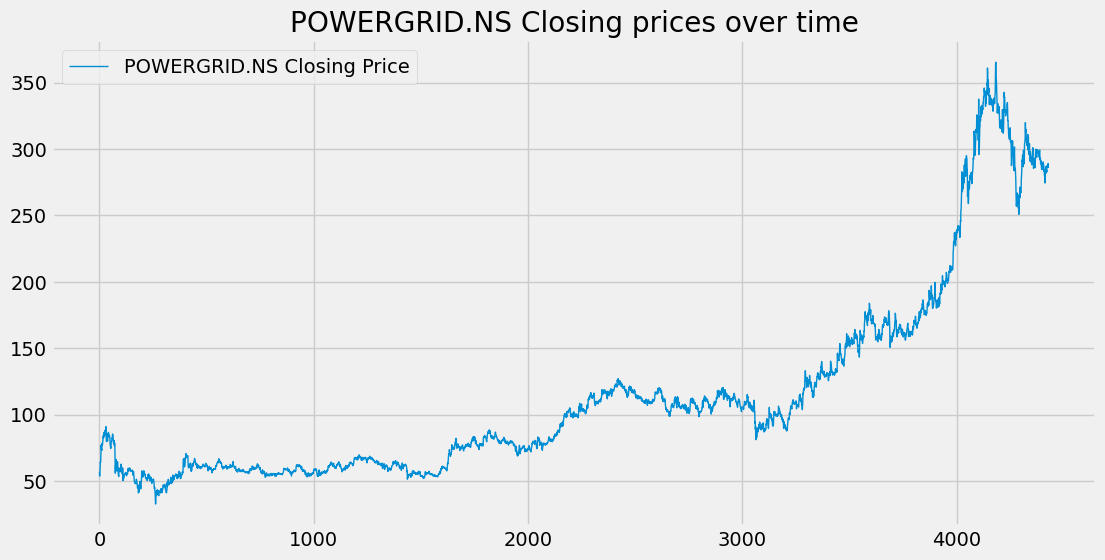

In [15]:
plt.figure(figsize=(12, 6))
plt.plot(df['Close'], label = f'{stock} Closing Price', linewidth = 1)
plt.title(f'{stock} Closing prices over time')
plt.legend()
plt.show()

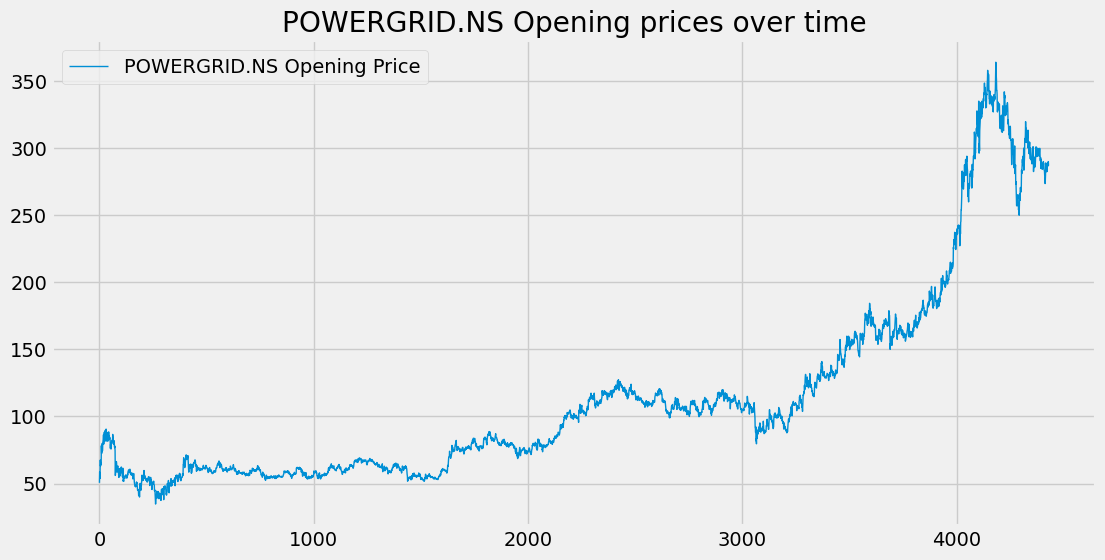

In [16]:
plt.figure(figsize=(12, 6))
plt.plot(df['Open'], label = f'{stock} Opening Price', linewidth = 1)
plt.title(f'{stock} Opening prices over time')
plt.legend()
plt.show()

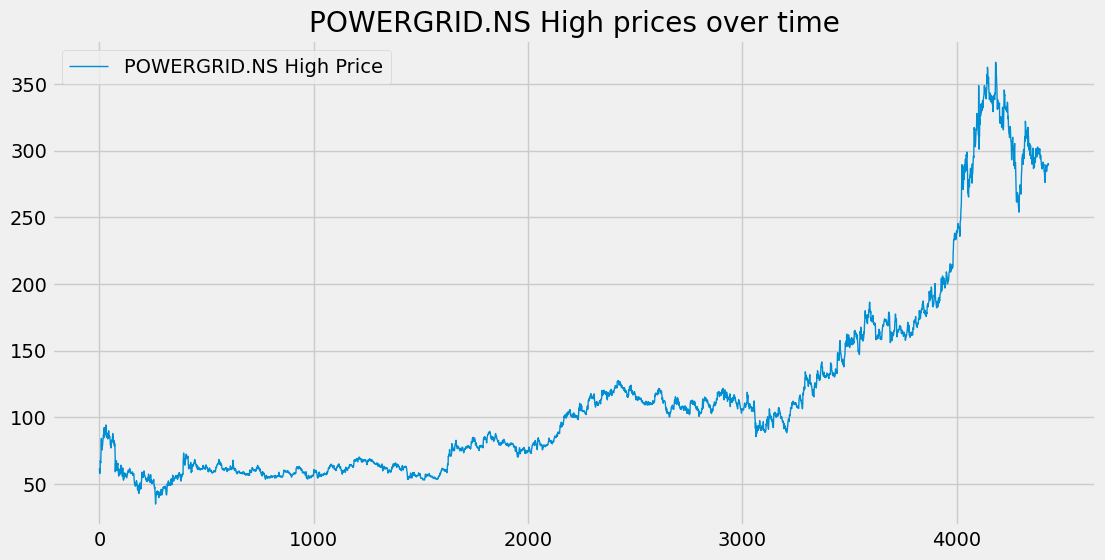

In [17]:
plt.figure(figsize=(12, 6))
plt.plot(df['High'], label = f'{stock} High Price', linewidth = 1)
plt.title(f'{stock} High prices over time')
plt.legend()
plt.show()

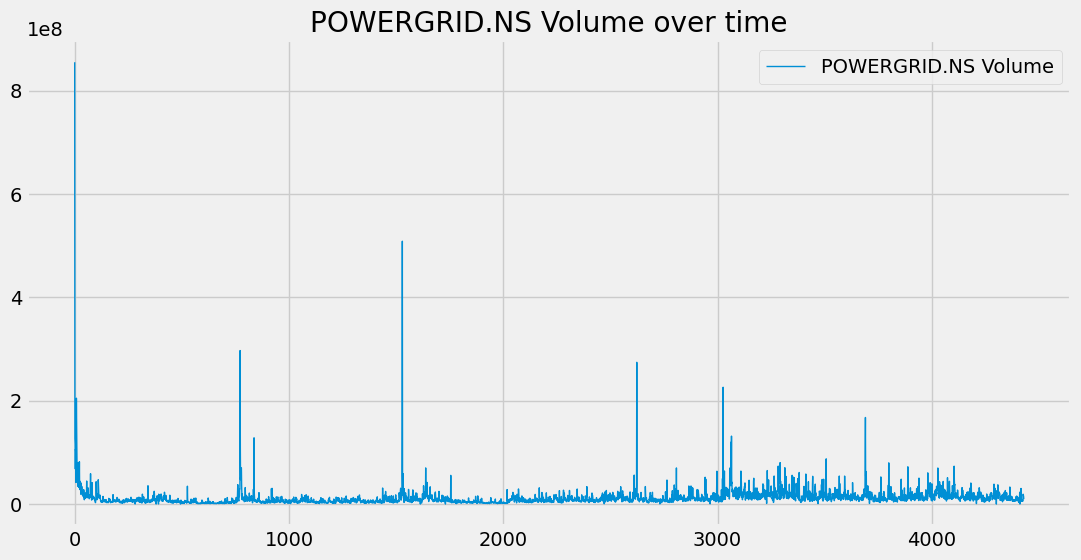

In [18]:
plt.figure(figsize=(12, 6))
plt.plot(df['Volume'], label = f'{stock} Volume', linewidth = 1)
plt.title(f'{stock} Volume over time')
plt.legend()
plt.show()

In [19]:
# Moving Average
# [10, 20, 30, 40, 50, 60, 70, 80, 90]
# moving average for last 5 days -> null null null null 30.0 40.0 50.0

temp_data = [10, 20, 30, 40, 50, 60, 70, 80, 90]
print(sum(temp_data[2:7])/5)

50.0


In [20]:
import pandas as pd
df01 = pd.DataFrame(temp_data)

In [21]:
df01.rolling(5).mean()

,0
0,NaN
1,NaN
2,NaN
3,NaN
4,30.0
5,40.0
6,50.0
7,60.0
8,70.0


In [22]:
ma100 = df.Close.rolling(100).mean()

In [23]:
ma100

Ticker,POWERGRID.NS
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
4425,292.6550
4426,292.4410
4427,292.3025
4428,292.0900


In [24]:
ma200 = df.Close.rolling(200).mean()

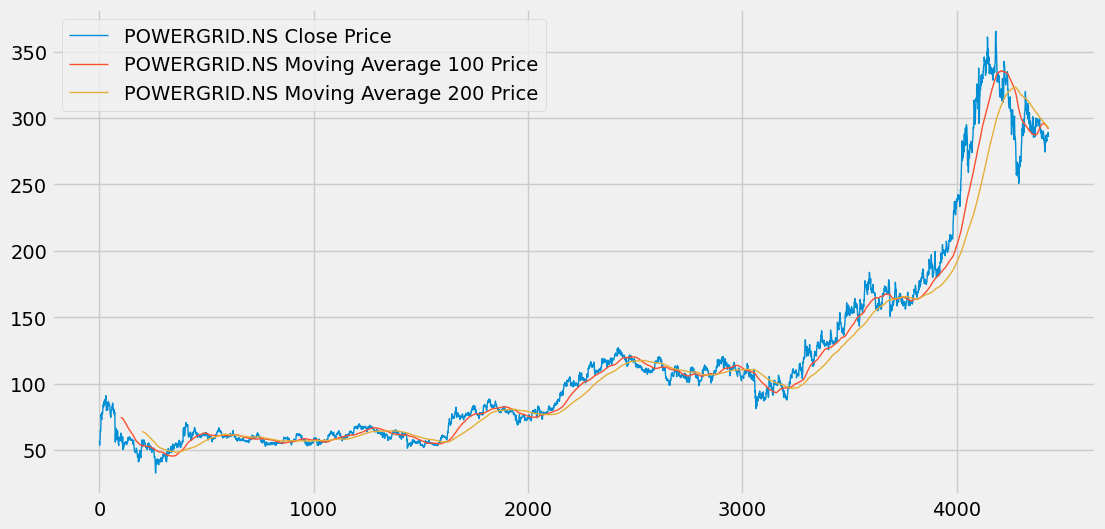

In [25]:
plt.figure(figsize=(12, 6))
plt.plot(df.Close, label = f'{stock} Close Price', linewidth = 1)
plt.plot(ma100, label = f'{stock} Moving Average 100 Price', linewidth = 1)
plt.plot(ma200, label = f'{stock} Moving Average 200 Price', linewidth = 1)
plt.legend()
plt.show()

In [26]:
ema100 = df.Close.ewm(span=100, adjust = False).mean()

In [27]:
ema200 = df['Close'].ewm(span=200, adjust = False).mean()

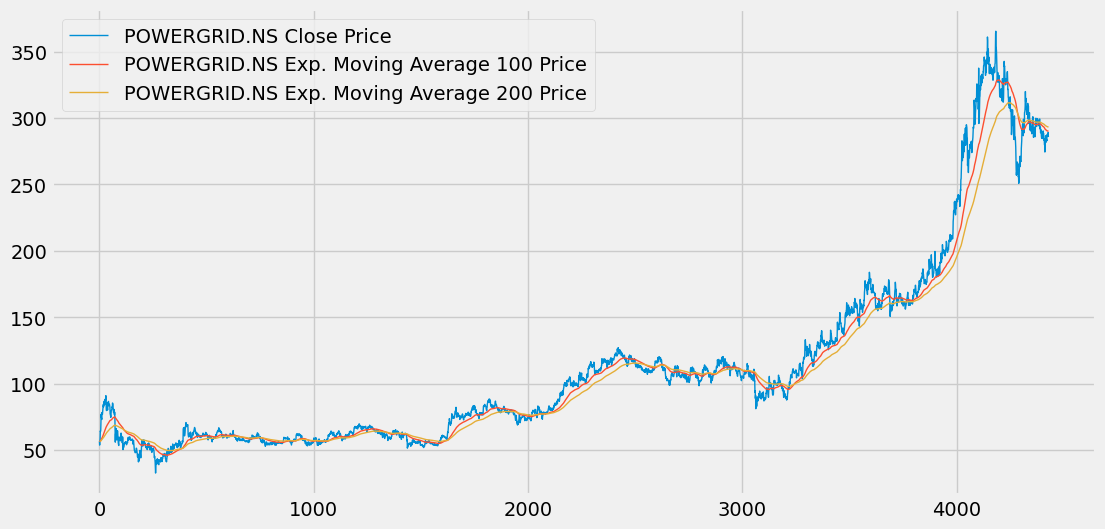

In [28]:
plt.figure(figsize=(12, 6))
plt.plot(df.Close, label = f'{stock} Close Price', linewidth = 1)
plt.plot(ema100, label = f'{stock} Exp. Moving Average 100 Price', linewidth = 1)
plt.plot(ema200, label = f'{stock} Exp. Moving Average 200 Price', linewidth = 1)
plt.legend()
plt.show()

In [29]:
# Training & Testing

data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing = pd.DataFrame(df['Close'][int(len(df)*0.70): int(len(df))])

In [30]:
data_training.shape

(3101, 1)

In [31]:
data_testing.shape

(1329, 1)

In [32]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range = (0, 1))

In [33]:
data_training_array = scaler.fit_transform(data_training)

In [34]:
data_training_array

array([[0.25364691],
       [0.22298304],
       [0.26168503],
       ...,
       [0.64691869],
       [0.61208689],
       [0.60613274]], shape=(3101, 1))

In [35]:
data_training_array.shape[0]

3101

In [41]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
    x_train.append(data_training_array[i-100:i])
    y_train.append(data_training_array[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)

In [42]:
x_train.shape

(3001, 100, 1)

In [43]:
# Model Building
from keras.layers import Dense, Dropout, LSTM
from keras.models import Sequential

In [44]:
model = Sequential()

model.add(LSTM(units = 50, activation = 'relu', return_sequences = True, input_shape = (x_train.shape[1],1)))
model.add(Dropout(0.2))

model.add(LSTM(units = 60, activation = 'relu', return_sequences = True))
model.add(Dropout(0.3))

model.add(LSTM(units = 70, activation = 'relu', return_sequences = True))
model.add(Dropout(0.4))

model.add(LSTM(units = 80, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units = 1))

In [45]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_4 (LSTM)                        │ (None, 100, 50)             │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 100, 50)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_5 (LSTM)                        │ (None, 100, 60)             │          26,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 100, 60)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_6 (LSTM)                        │ (None, 100, 70)             │          36,680 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 100, 70)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_7 (LSTM)                        │ (None, 80)                  │          48,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 80)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              81 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 122,121 (477.04 KB)

 Trainable params: 122,121 (477.04 KB)

 Non-trainable params: 0 (0.00 B)

In [46]:
model.compile(optimizer = 'adam', loss = 'mean_squared_error')
model.fit(x_train, y_train, epochs = 50)

Epoch 1/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 25s 187ms/step - loss: 0.0395
Epoch 2/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 19s 201ms/step - loss: 0.0121
Epoch 3/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 192ms/step - loss: 0.0103
Epoch 4/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 19s 197ms/step - loss: 0.0096
Epoch 5/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 19s 197ms/step - loss: 0.0081
Epoch 6/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 17s 178ms/step - loss: 0.0079
Epoch 7/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 17s 180ms/step - loss: 0.0077
Epoch 8/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 19s 200ms/step - loss: 0.0066
Epoch 9/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 19s 205ms/step - loss: 0.0066
Epoch 10/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 195ms/step - loss: 0.0064
Epoch 11/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 18s 189ms/step - loss: 0.0054
Epoch 12/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 19s 207ms/step - loss: 0.0055
Epoch 13/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 19s 202ms/step - loss: 0.0049
Epoch 14/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 21s 224ms/step - loss: 0.0046
Epoch 15/50
94/94 ━━━━━━━━━━━━━━━━━━━━ 41s 

In [47]:
past_100_days = data_training.tail(100)

In [48]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)

In [49]:
final_df.head()

Ticker,POWERGRID.NS
0,105.300026
1,104.850029
2,104.681274
3,104.512527
4,105.271904


In [50]:
input_data = scaler.fit_transform(final_df)

In [51]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
    x_test.append(input_data[i-100:i])
    y_test.append(input_data[i, 0])

x_test, y_test = np.array(x_test), np.array(y_test)

In [52]:
x_test.shape

(1329, 100, 1)

In [53]:
y_predicted = model.predict(x_test)

42/42 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step


In [54]:
y_predicted.shape

(1329, 1)

In [55]:
scaler.scale_

array([0.0035166])

In [56]:
scaler_factor = 1 / 0.0035166
y_predicted = y_predicted * scaler_factor
y_test = y_test * scaler_factor

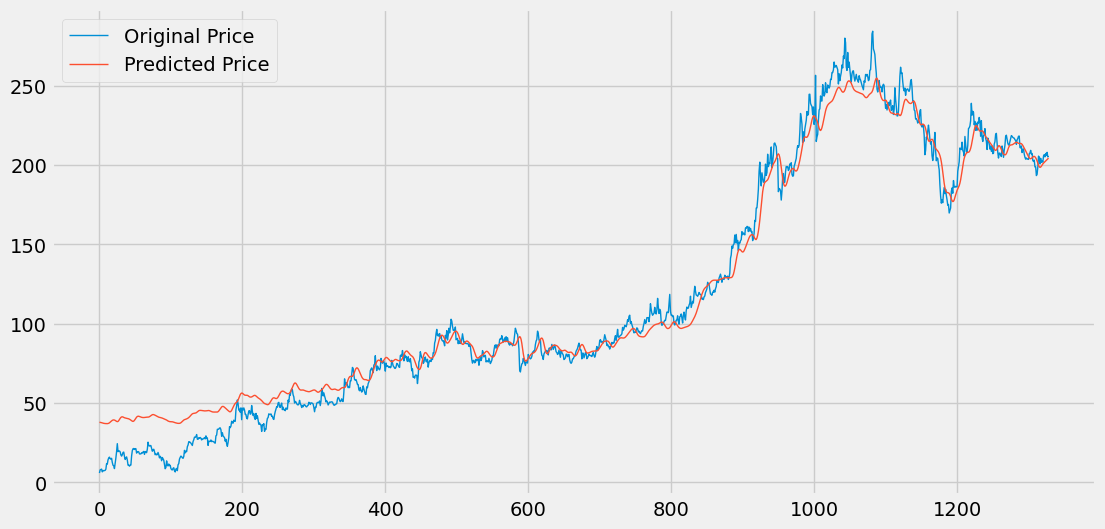

In [57]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, label = 'Original Price', linewidth = 1)
plt.plot(y_predicted, label = 'Predicted Price', linewidth = 1)
plt.legend()
plt.show()

In [59]:
model.save('stock_dl_model.keras')